<a href="https://colab.research.google.com/github/davidmkidd/UK-Supermarket-Carbon-Emissions/blob/main/UKSmktComp_Intensity_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://evoviz.uk/wp-content/uploads/2026/04/Food_Divider_trans2.png">

# Estimated and Reported Intensity

Scope 1 and Scope 2 location-based metrics scale with total retailer store area but not store number, and estimated area-based intensity differs considerably from reported intensity figures.

This workbook futher evaluates the relationship between estimated and reported  Scope 1 and 2 location-based intensity metrics.

# Set-up



In [ ]:
# Load libraries
library(dplyr)   # Data manipulation
library(ggplot2) # Graphing
library(repr)    # Graph size
options(repr.plot.width = 10, repr.plot.height = 8)
library(broom)   # Format model output
library(knitr)    # Format model output

# Download cleaned and summarised emmissions data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_emissions_yr.csv"
download_path <- "/content/retailer_emissions_yr.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
emissions.yr <- read.csv("/content/retailer_emissions_yr.csv", header=TRUE, stringsAsFactors=FALSE)

# Download retailer data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_data.csv"
download_path <- "/content/retailer_data.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
retailer.data <- read.csv("/content/retailer_data.csv", header=TRUE, stringsAsFactors=FALSE)


# Make palette list
retailer.pal <- setNames(retailer.data$hex, retailer.data$retailer_code)
# Make code/name list
retailer.code <- setNames(retailer.data$retailer, retailer.data$retailer_code)

# Truncate year to 1s and 10s
emissions.yr$year2 <- emissions.yr$year - 2000

# Split reported absolute and intenstity values into seperate data frames as they will will be used differenty.

# Reported Absolute Values
emissions.yr.absolute <- emissions.yr %>%
   filter(kpi_type == "Measure")
nrow(emissions.yr.absolute)

# Reported Intensity Values
emissions.yr.intensity <- emissions.yr %>%
   filter(kpi_type == "Intensity")
nrow(emissions.yr.intensity)


# Calculate estimated intensity for absolute values
emissions.yr.absolute$intensity <- emissions.yr.absolute$value/emissions.yr.absolute$total_area


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] 595

[1] 184

# Reported Area-based Intensity

Area-based metrics are caculated by dividing emissions by a measure of the land surface taken up by its operations.

## Data
Get data.

In [ ]:

# Intensity estimated from reported figures standardised by retailer store area
data.abs <- emissions.yr.absolute %>%
  filter(kpi == "Scope 1 and 2" & unit == "tCO2e" & method == "Location")
nrow(data.abs)

# Intensity reported by retailer
data.int <- emissions.yr.intensity %>%
  filter(kpi == "Scope 1 and 2"  & unit_neum == "tCO2e" & unit_denom_1 == "m2" & method == "Location")
nrow(data.int)

# Join absolute and intensity data frames
data.scatter <- merge(data.abs, data.int,
   by.x = c("retailer_code","year"), by.y = c("retailer_code","year"))

data.scatter <- data.scatter %>% rename(estimated = intensity, reported = value.y, year2 = year2.x)
data.scatter <- arrange(data.scatter, retailer_code, year)

[1] 105

[1] 45

Plot reported intensity time series.

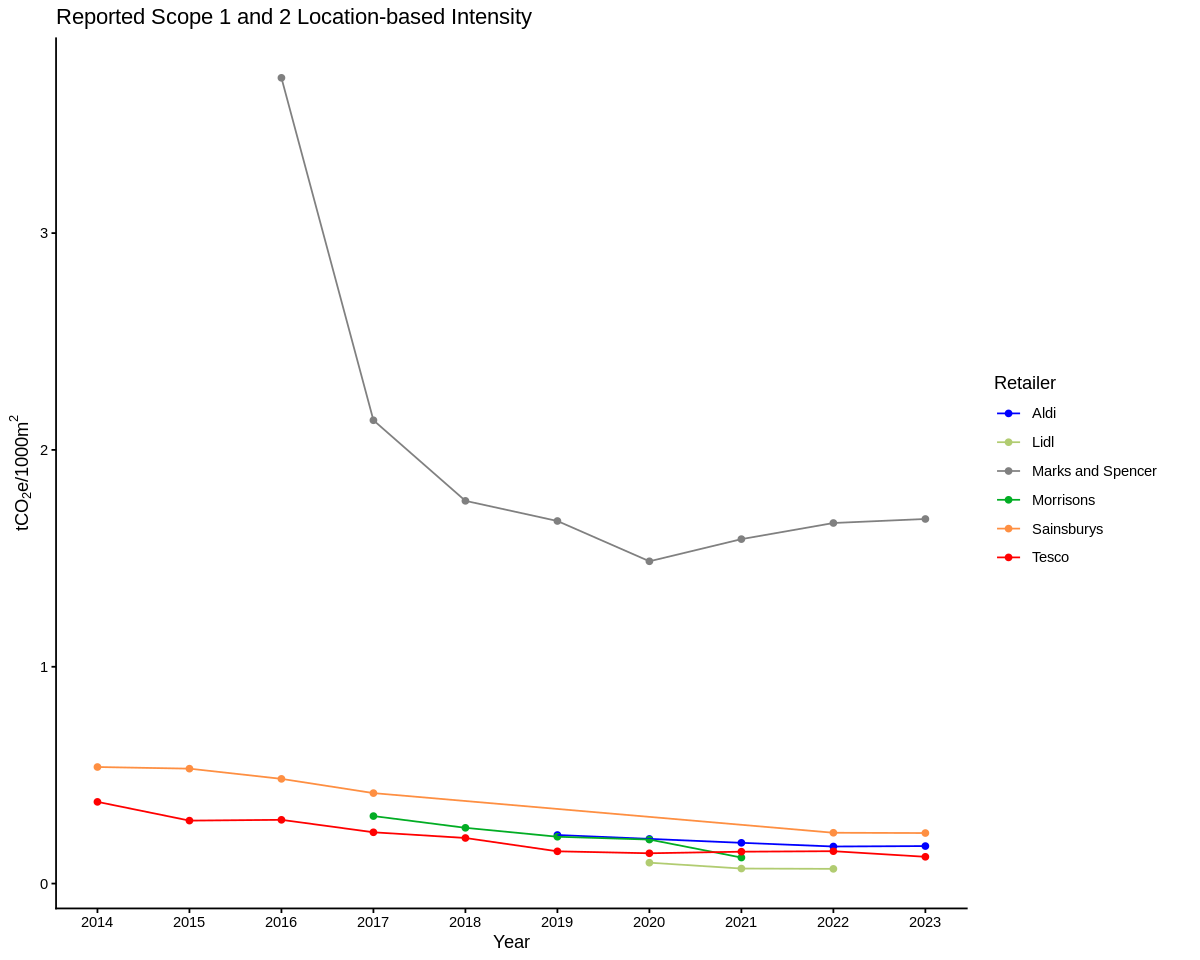

In [ ]:
ggplot(data.scatter , aes(x = year, y = reported, colour = retailer_code)) +
  geom_point(, na.rm = TRUE) +
  geom_line(na.rm = TRUE) +
  ggtitle("Reported Scope 1 and 2 Location-based Intensity") +
  xlab("Year") +
  ylab(expression(paste("tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(2014, 2023), breaks=seq(2014,2023)) +
  theme_classic()

* Six retailers report area-scaled Scope 1 and 2 location-based emissions.
* M&S reported intensity is four times greater than other retailers.

How do estimated and reported values vary?

Plot Estimated and Reported Intensity.

Values are plotted as points temporally connected by the ` geom_path()` line and are mostly oriented towards the origin and retailers lower their carbon intensity.

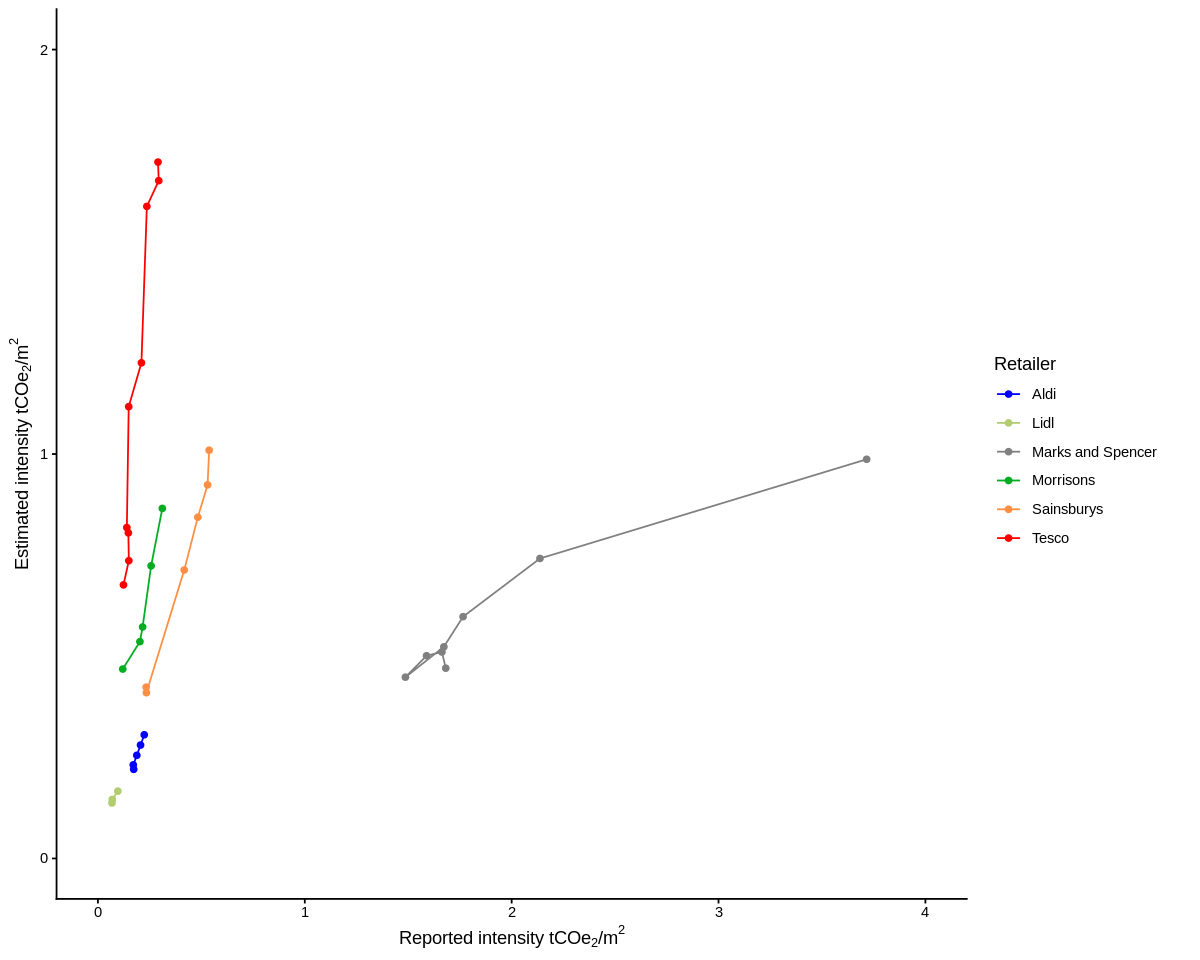

In [ ]:
ggplot(data.scatter, aes(x = reported, y = estimated, colour = retailer_code) +
  geom_point(na.rm = TRUE) +
  geom_path(na.rm = TRUE) +
  xlab(expression(paste("Reported intensity tCOe"[2], "/m"^2))) +
  ylab(expression(paste("Estimated intensity tCOe"[2], "/m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0,4), breaks = seq(0, 4)) +
  scale_y_continuous(limits = c(0,2), breaks = seq(0, 4)) +
  theme_classic()

* Within retailers, estimated and reported intensity is approximately linear, but slope varies between retailers.

* Marks and Spencer reports considerably higher intensities than other retailers or are estimated.

Excluding Marks and Spencer reveals more detail and the similarity in slope between Aldi, Lidl, Sainsburys, and Morrisons.

In [ ]:
data.scatter.no.ms <- data.scatter %>%
  filter(retailer_code != "M&S")

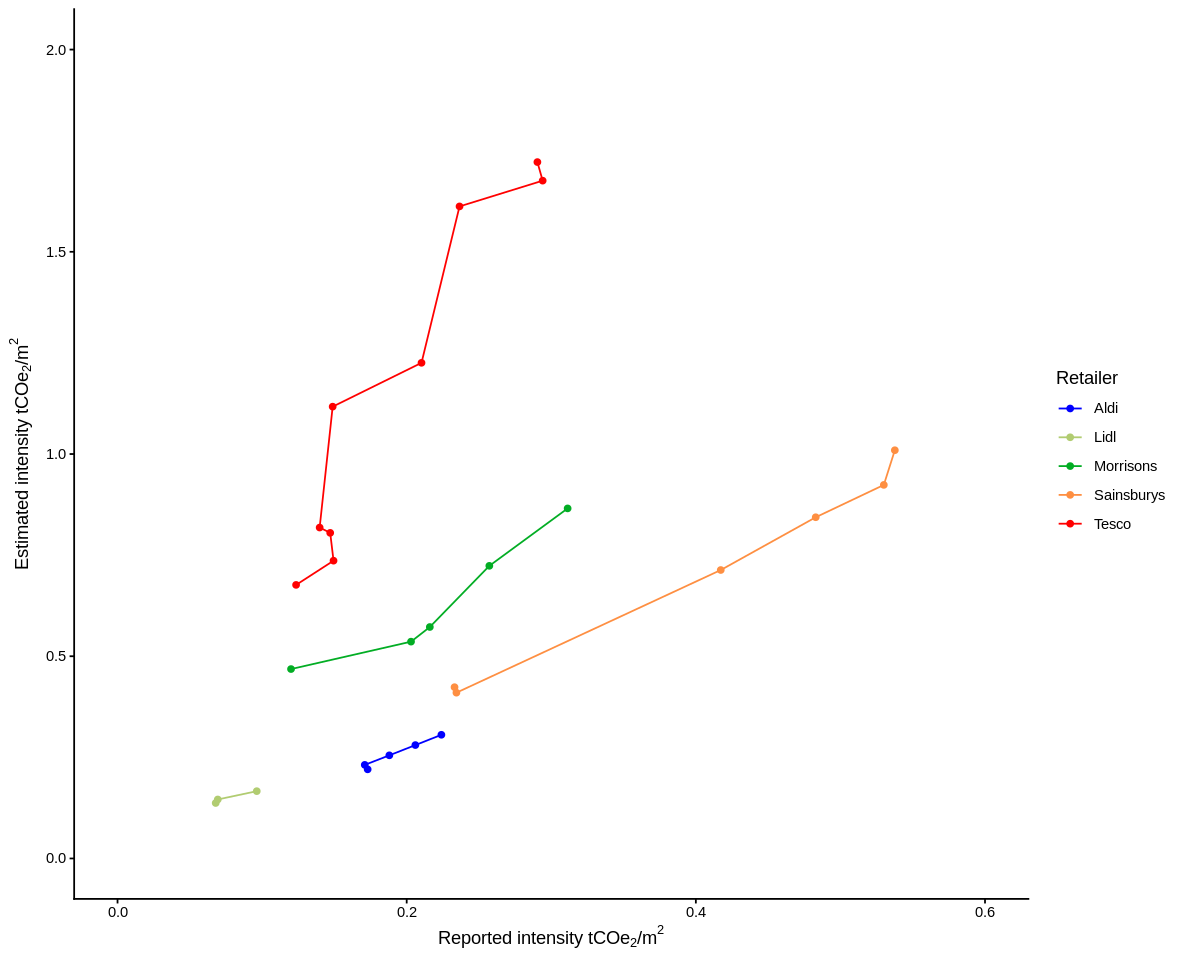

In [ ]:

ggplot(data.scatter.no.ms, aes(x = reported, y = estimated, colour = retailer_code)) +
  geom_point(na.rm = TRUE) +
  geom_path(na.rm = TRUE) +
  xlab(expression(paste("Reported intensity tCOe"[2], "/m"^2))) +
  ylab(expression(paste("Estimated intensity tCOe"[2], "/m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0,0.6)) +
  scale_y_continuous(limits = c(0,2)) +
  theme_classic()

## Linear Regression

The strength of relationship between estimated and reported intensity is tested with linear regression.

`geom_smooth(method='lm', formula = y ~ x, na.rm = TRUE)` adds a linear regression to a plot with 95% confidence intervals.

`annotate(...)` adds a dashed parity line.


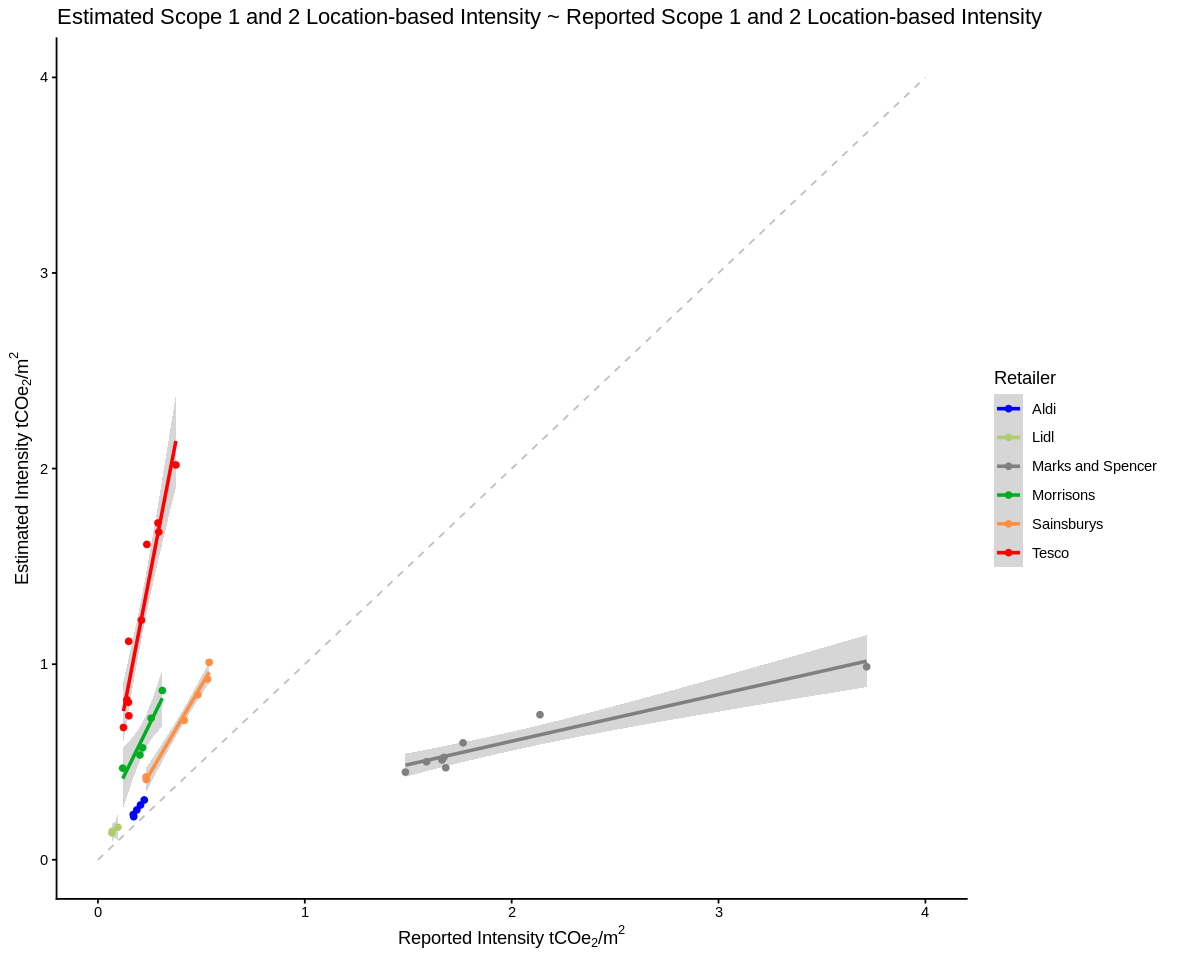

In [ ]:
# Estimated Scope 1 and 2 Location-based Intensity ~ Reported Scope 1 and 2 Location-based Intensity
ggplot(data.scatter, aes(x = reported, y = estimated, colour = retailer_code)) +
  geom_smooth(method='lm', formula = y ~ x, na.rm = TRUE) +
  geom_point(na.rm = TRUE) +
  annotate(geom = "segment", x = 0, y = 0, xend = 4, yend = 4,
    colour = "grey", linewidth = 0.5, linetype = "dashed") +
  ggtitle("Estimated Scope 1 and 2 Location-based Intensity ~ Reported Scope 1 and 2 Location-based Intensity") +
  xlab(expression(paste("Reported Intensity tCOe"[2], "/m"^2))) +
  ylab(expression(paste("Estimated Intensity tCOe"[2], "/m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0,4), breaks = seq(0, 4)) +
  scale_y_continuous(limits = c(0,4), breaks = seq(0, 4)) +
  theme_classic()

Formatted tables of model fit statistics are printed by looping though a list of retailers in *data.scatter*. Data for each retailer is filtered, a linear model constructed, and model and variable fit statitics formatted with broom.`glance()` and `knitr.kable()`.


In [ ]:
# Fit Statistics for each retailer
ret <- unique(data.scatter$retailer_code)

for (r in ret) {

  print("")
  print(paste("Retailer:", r))
  print("------------")

  r.data <- filter(data.scatter, retailer_code == r)
  lm_model <- lm(data = r.data, reported ~ estimated, na.action=na.omit)
  print(glance(lm_model) %>%
    kable(digits = 3))
  print(tidy(lm_model) %>%
    kable(digits = 3))

}

[1] ""
[1] "Retailer: ALDI"
[1] "------------"


| r.squared| adj.r.squared| sigma| statistic| p.value| df| logLik|     AIC|     BIC| deviance| df.residual| nobs|
|---------:|-------------:|-----:|---------:|-------:|--:|------:|-------:|-------:|--------:|-----------:|----:|
|     0.976|         0.968| 0.004|   123.311|   0.002|  1|  21.77| -37.539| -38.711|        0|           3|    5|


|term        | estimate| std.error| statistic| p.value|
|:-----------|--------:|---------:|---------:|-------:|
|(Intercept) |    0.028|     0.015|     1.871|   0.158|
|estimated   |    0.636|     0.057|    11.105|   0.002|
[1] ""
[1] "Retailer: LIDL"
[1] "------------"


| r.squared| adj.r.squared| sigma| statistic| p.value| df| logLik|     AIC|     BIC| deviance| df.residual| nobs|
|---------:|-------------:|-----:|---------:|-------:|--:|------:|-------:|-------:|--------:|-----------:|----:|
|     0.938|         0.876| 0.006|    15.164|    0.16|  1| 12.931| -19.862| -22.567|        0|           1

To get sample sizes:

In [ ]:
table(data.scatter$retailer_code)


 ALDI  LIDL   M&S  MORR SAINS  TESC 
    5     3     8     6     9    14 

* Estimated intensity is highly linear with reported intensity with > 90% of variation in all retailers explained. All models are significant with *p* < 0.05 except Lidl that has a very small sample size of just 3.

**Conclusions**

* Total store area-based intensity is highly linear with reported area-based metrics within retailers, but differs between retailers and does not work for online retailers

* All retailers except M&S have higher estimated intensity than reported.

* Difference between reported and estimated intensity may reflect:
  * Different intensity divisors.
  * Alternative business models and operation.
  * Calculation error.
  
For example,

* Tesco report intensity scaled to a larger area so expect estimated values to overestimate which they do.

* Lidl, Aldi and Morrsions report intensity scaled to sales area which may be lower so expect underestimation, however all are overestimated albeit less than Tesco.

* The considerable difference between M&S and other retailers may arise from how its business model differs, e.g. a historical emphasis on clothes that has shifted to groceries that in 2022 accounted for [60.7% of revenue](https://corporate.marksandspencer.com/media/press-releases/full-year-results-for-52-weeks-ended-2-april-2022).



# Reported Revenue-based Intensity



## Data
Total revenue is the total income a business earns from selling goods or services before any expenses are deducted.

In [ ]:
# Revenue-based Intensity reported by retailer

data.int <- emissions.yr.intensity %>%
  filter(kpi == "Scope 1 and 2" & method == "Location"  & unit_neum == "tCO2e" & unit_denom_1 == "mGBP")
nrow(data.int)

data.int %>%
  filter(unit_denom_1 == 'mGBP') %>%
  group_by(retailer_code) %>%
  count()

[1] 29

retailer_code,n
<chr>,<int>
ALDI,5
COOP,13
ICE,5
MORR,6


Four retailers have published revenue-based intensity metrics.

In [ ]:
# Intensity estimated from reported figures standardised by retailer store area
data.abs <- emissions.yr.absolute %>%
  filter(kpi == "Scope 1 and 2" & unit == "tCO2e" & method == "Location")
nrow(data.abs)


# Join absolute and intensity data frames
data.scatter <- merge(data.abs, data.int,
   by.x = c("retailer_code","year"), by.y = c("retailer_code","year"))

# Tidy and Sort
data.scatter <- data.scatter %>% rename(estimated = intensity, reported = value.y, year2 = year2.x)
data.scatter <- arrange(data.scatter, retailer_code, year)
nrow(data.scatter)

[1] 105

[1] 29

Plot reported revenue intensity time series.

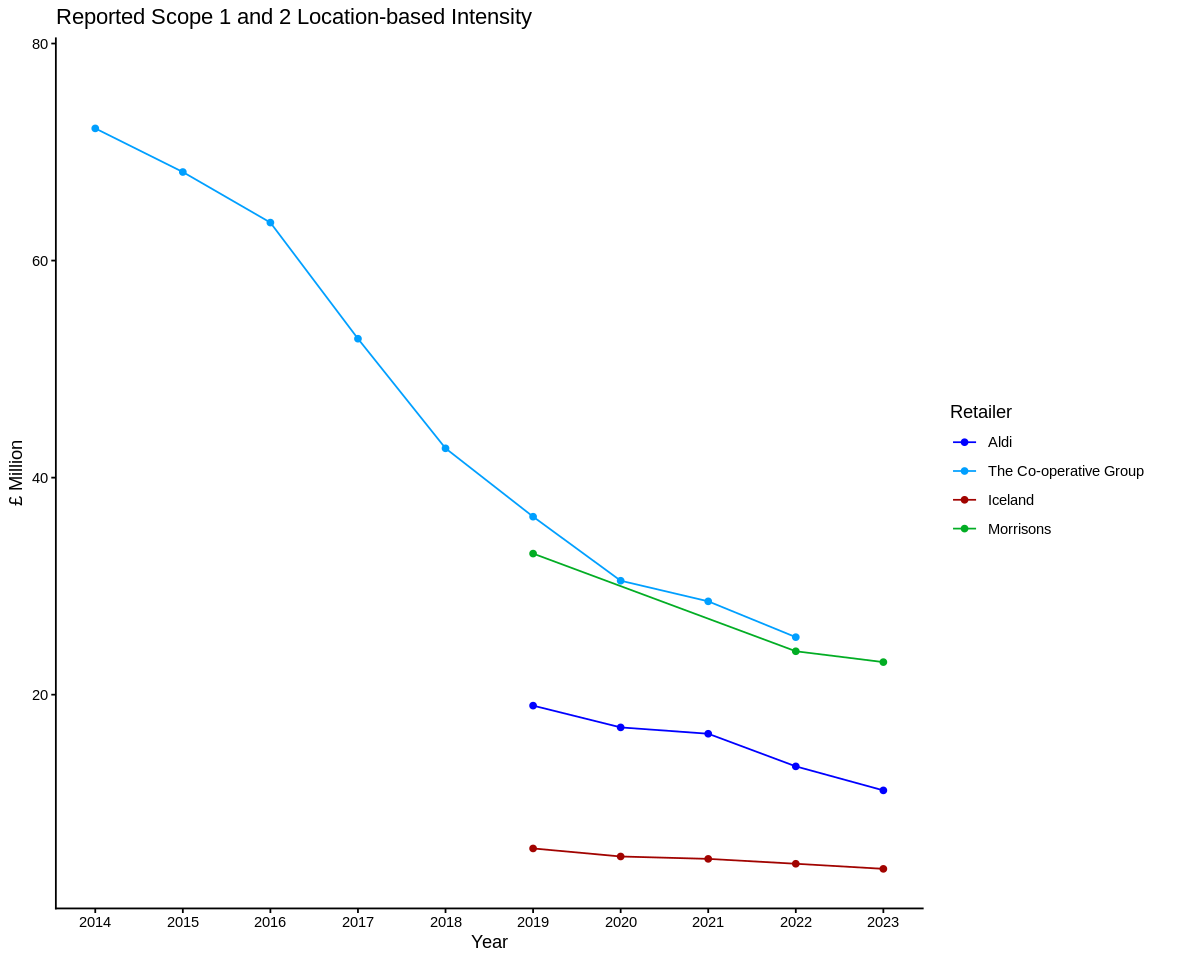

In [ ]:
ggplot(data.scatter , aes(x = year, y = reported, colour = retailer_code)) +
  geom_point(, na.rm = TRUE) +
  geom_path(na.rm = TRUE) +
  ggtitle("Reported Scope 1 and 2 Location-based Intensity") +
  xlab("Year") +
  ylab(expression(paste("£ Million"))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(2014, 2023), breaks=seq(2014,2023)) +
  theme_classic()

* All four retailers show a decreasing trend in emissions intenstiy.


Plot reported revenue intensity against estimated area-based intensity.

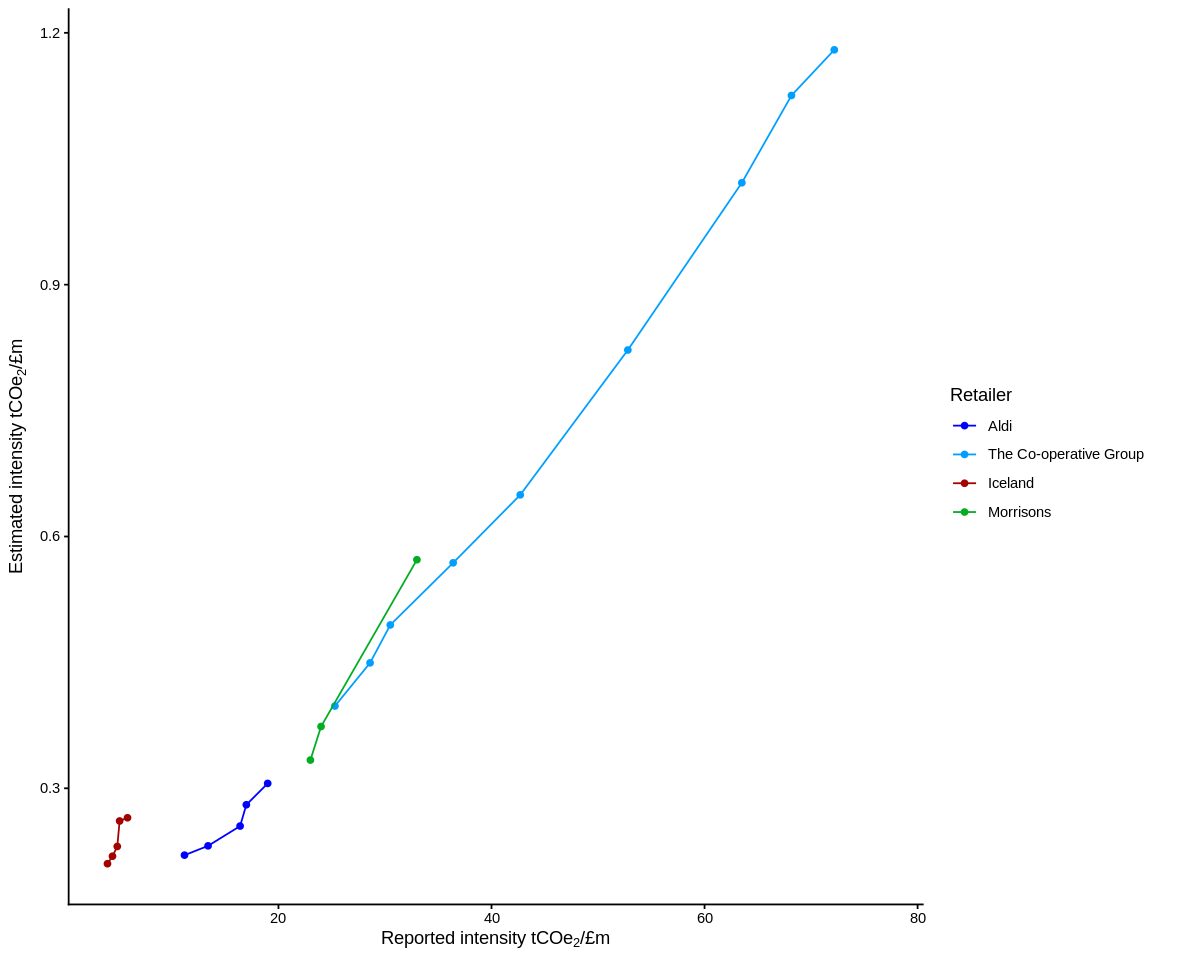

In [ ]:
ggplot(data.scatter, aes(x = reported, y = estimated, colour = retailer_code, label = year2)) +
  geom_point(na.rm = TRUE) +
  geom_path(na.rm = TRUE) +
  xlab(expression(paste("Reported intensity tCOe"[2], "/£m"))) +
  ylab(expression(paste("Estimated intensity tCOe"[2], "/£m"))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()

* Three retailers have very similar linear relationships between reported revenue-based intensity and estimated area-based intensity.

* Iceland has a lower revenue-based intensity compared to the other retailers.

## Linear Regression

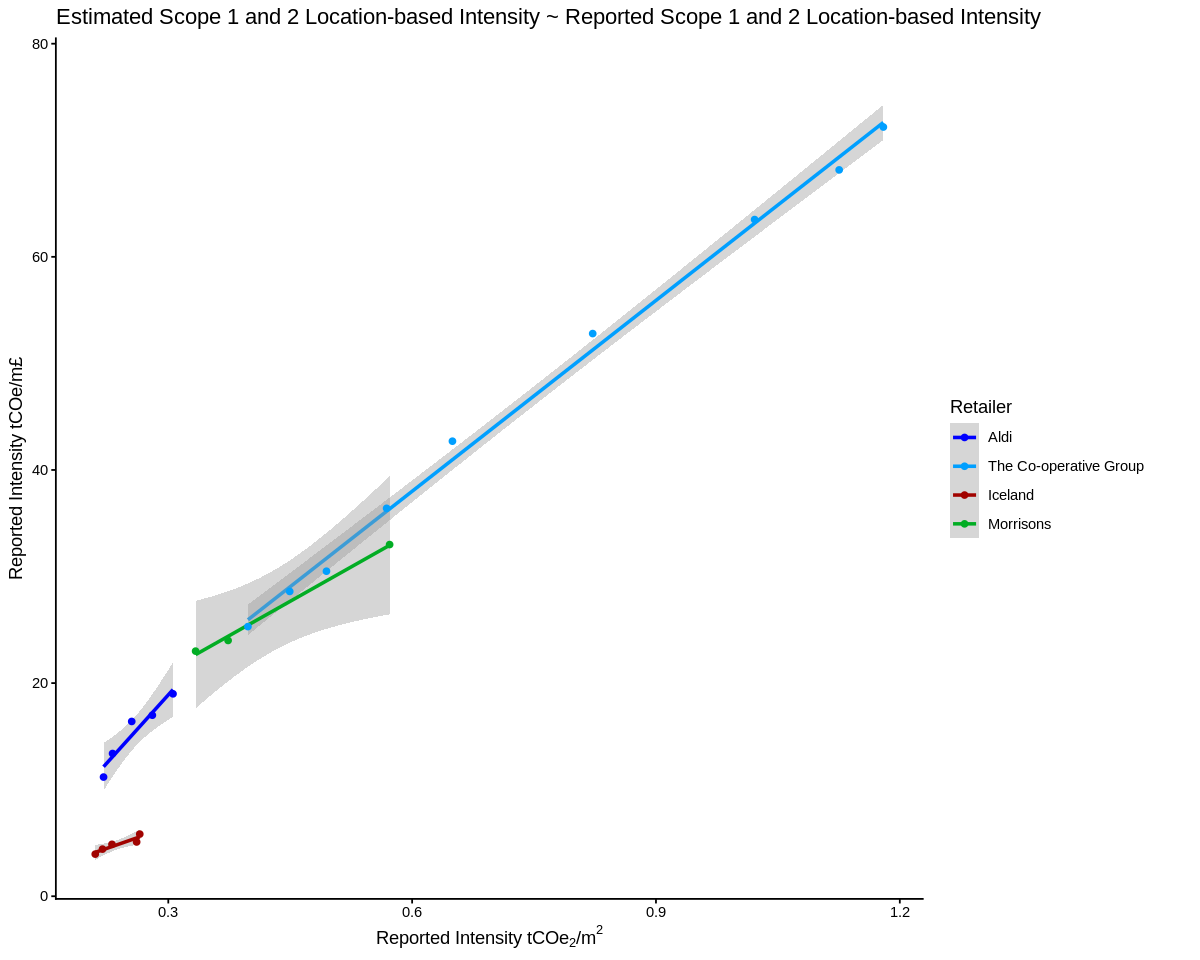

In [ ]:
# Estimated Scope 1 and 2 Location-based Intensity ~ Reported Scope 1 and 2 Location-based Intensity
ggplot(data.scatter, aes(x = estimated, y = reported, colour = retailer_code)) +
  geom_smooth(method='lm', formula = y ~ x, na.rm = TRUE) +
  geom_point(na.rm = TRUE) +
  ggtitle("Estimated Scope 1 and 2 Location-based Intensity ~ Reported Scope 1 and 2 Location-based Intensity") +
  xlab(expression(paste("Reported Intensity tCOe"[2], "/mGDP"))) +
  ylab("Reported Intensity tCOe/m£") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()

In [ ]:
# Fit Statistics
ret <- unique(data.scatter$retailer_code)
for (r in ret) {
  print(paste("Retailer:", r))
  r.data <- filter(data.scatter, retailer_code == r)
  lm_model <- lm(data = r.data, reported ~ estimated, na.action=na.omit)
  print(glance(lm_model) %>%
    kable(digits = 3))
  print(tidy(lm_model) %>%
    kable(digits = 3))
}

[1] "Retailer: ALDI"


| r.squared| adj.r.squared| sigma| statistic| p.value| df| logLik|    AIC|    BIC| deviance| df.residual| nobs|
|---------:|-------------:|-----:|---------:|-------:|--:|------:|------:|------:|--------:|-----------:|----:|
|     0.922|         0.896| 0.996|     35.53|   0.009|  1| -5.798| 17.596| 16.424|    2.977|           3|    5|


|term        | estimate| std.error| statistic| p.value|
|:-----------|--------:|---------:|---------:|-------:|
|(Intercept) |   -6.510|     3.701|    -1.759|   0.177|
|estimated   |   84.685|    14.207|     5.961|   0.009|
[1] "Retailer: COOP"


| r.squared| adj.r.squared| sigma| statistic| p.value| df|  logLik|    AIC|    BIC| deviance| df.residual| nobs|
|---------:|-------------:|-----:|---------:|-------:|--:|-------:|------:|------:|--------:|-----------:|----:|
|     0.996|         0.996|  1.15|  1957.971|       0|  1| -12.898| 31.797| 32.389|     9.26|           7|    9|


|term        | estimate| std.error| statistic| p.va

In [ ]:
table(data.scatter$retailer_code)


ALDI COOP  ICE MORR 
   5   13    5    3 

* Estimated intensity by store area is strongly linear with intensity by sales revenue, and is significant for three of four retailers despite low sample size.

* Slopes are similar for all retailers.

## Single Model

To test if revenue intensity is linear with store number and area.

In [ ]:
# Single linear model
# Calculate Mean for recent years
data.abs.mean <- data.abs %>%
  filter(year >= 2019 & year < 2023) %>%
  group_by(retailer_code) %>%
  summarise_at(vars(value, total_store, total_area),list(mean = mean))

In [ ]:
# Linear Regression Scope 1 and 2 Location-based ~ Store Number
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean, na.action=na.omit)
print("Store Number:")
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)

[1] "Store Number:"




| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.515|         0.446| 409587.8|     7.444|   0.029|  1| -127.946| 261.891| 262.483| 1.174335e+12|           7|    9|



|term             |   estimate|  std.error| statistic| p.value|
|:----------------|----------:|----------:|---------:|-------:|
|(Intercept)      | -132126.88| 272134.266|    -0.486|   0.642|
|total_store_mean |     516.13|    189.175|     2.728|   0.029|

In [ ]:
# Linear Regression Scope 1 and 2 Location-based ~ Store Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_area_mean, na.action=na.omit)
print("Store Area:")
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)

[1] "Store Area:"




| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|      0.89|         0.875| 194789.6|    56.862|       0|  1| -121.257| 248.513| 249.105| 265600913883|           7|    9|



|term            |    estimate| std.error| statistic| p.value|
|:---------------|-----------:|---------:|---------:|-------:|
|(Intercept)     | -467106.182| 144952.28|    -3.222|   0.015|
|total_area_mean |       0.979|      0.13|     7.541|   0.000|

In [ ]:
# Linear Regression Scope 1 and 2 Location-based ~ Store Number + Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean + total_area_mean, na.action=na.omit)
print("Store Number and Area:")
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)

[1] "Store Number and Area:"




| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.911|         0.881| 189942.6|    30.581|   0.001|  2| -120.336| 248.672| 249.461| 216469262017|           6|    9|



|term             |    estimate|  std.error| statistic| p.value|
|:----------------|-----------:|----------:|---------:|-------:|
|(Intercept)      | -509263.459| 145888.955|    -3.491|   0.013|
|total_store_mean |     134.048|    114.869|     1.167|   0.288|
|total_area_mean  |       0.854|      0.166|     5.153|   0.002|

* Store Area is the best predictor of revenue intensity.

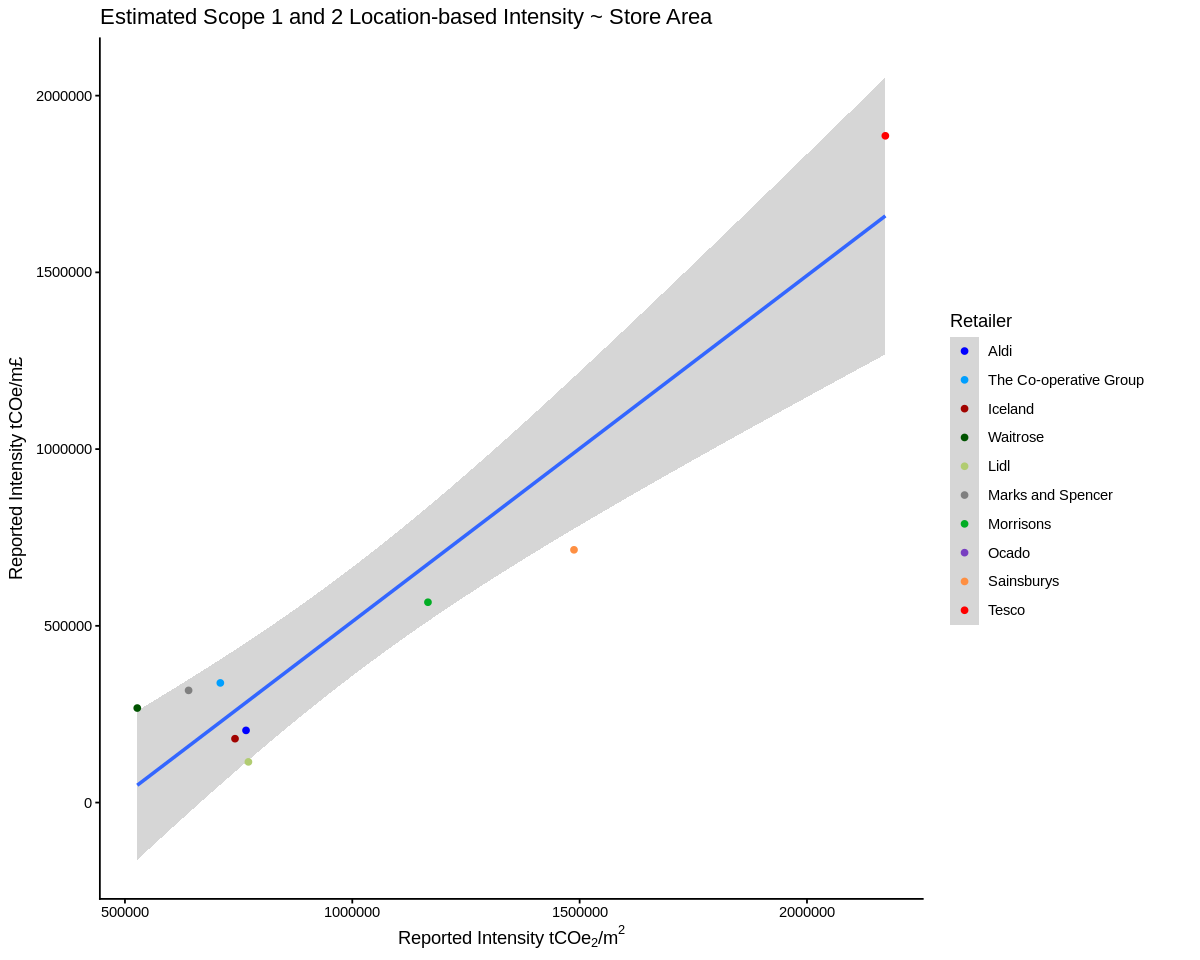

In [ ]:
ggplot(data.abs.mean, aes(x = total_area_mean, y = value_mean, colour = retailer_code)) +
  geom_smooth(method='lm', formula = y ~ x, na.rm = TRUE, aes(colour = NULL)) + # Remove colour from geom_smooth for a single line
  geom_point(na.rm = TRUE) +
  ggtitle("Estimated Scope 1 and 2 Location-based Intensity ~ Store Area") +
  xlab(expression(paste("Reported Intensity tCOe"[2], "/m"^2))) +
  ylab("Reported Intensity tCOe/m£") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  guides(colour = guide_legend(override.aes = list(linetype = 0))) +
  theme_classic()

---

[Main Page](https://colab.research.google.com/drive/1f8a0pXfF9PqCujiwjf4TO4-k7ezt-6b3?usp=sharing)

[Emissions Comparison](https://colab.research.google.com/drive/1rFQkcCglWdR4Ndo8hgcVfazS7N-uuJsG?usp=sharing)

---

